In [3]:
from langchain_groq import ChatGroq
from langchain_google_genai import GoogleGenerativeAIEmbeddings

from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from typing import TypedDict, Annotated

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun

from langchain_core.messages import BaseMessage, HumanMessage
from dotenv import load_dotenv
load_dotenv()

from langchain_mcp_adapters.client import MultiServerMCPClient

In [4]:
# model
model = ChatGroq(model="openai/gpt-oss-120b", temperature=0.4)

In [11]:
# loader
loader = PyMuPDFLoader("docs/islr.pdf")
docs = loader.load()

In [12]:
len(docs)

441

In [13]:
# splitter
splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 200)
chunks = splitter.split_documents(docs)

In [14]:
len(chunks)

1349

In [15]:
# embeddings
embeddings = GoogleGenerativeAIEmbeddings(model="models/text-embedding-004")

In [16]:
# vector-store
vector_store = FAISS.from_documents(chunks, embeddings)
vector_store

In [17]:
# retriver
retriver = vector_store.as_retriever(search_type = 'similarity', search_kwargs = {'k':4})

In [51]:
@tool
def rag_tool(query):
      """
      Retrieve relevant information from the pdf document. 
      Use this tool when the user asks factual / conceptual questions 
      that might be answered from the stored documents.
      """

      result = retriver.invoke(query)

      context = [doc.page_content for doc in result]
      metadata = [doc.metadata for doc in result]

      return {
            'query' : query,
            'context' : context,
            'metadata' : metadata
      }

In [52]:
tools = [rag_tool]
llm_with_tools = model.bind_tools(tools)

In [53]:
class ChatState(TypedDict):
      messages : Annotated[list[BaseMessage], add_messages]

In [54]:
def chat_node(state : ChatState) -> ChatState:

      messages = state['messages']

      response = llm_with_tools.invoke(messages)

      return {'messages' : [response]}

In [55]:
# tool node
tool_node = ToolNode(tools)

In [56]:
def main_llm_function(state : ChatState) -> ChatState:

      # take user quey from state
      messages = state['messages']

      # send query to llm
      response = llm_with_tools.invoke(messages)

      # save response in the state
      return {"messages" : [response]}


In [57]:
graph = StateGraph(ChatState)

graph.add_node("main_llm_function", main_llm_function)
graph.add_node("tools", tool_node)
    
graph.add_edge(START, "main_llm_function")
graph.add_conditional_edges("main_llm_function", tools_condition)
graph.add_edge("tools", "main_llm_function")

chatbot = graph.compile()

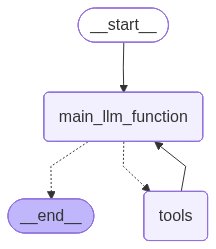

In [58]:
from IPython.display import Image
Image(chatbot.get_graph().draw_mermaid_png())

In [61]:
result = chatbot.invoke(
      {
            "messages" : [
                  HumanMessage(
                        content = "Using the pdf notes, explain how to split a node in decision tree"
                  )
            ]
      }
)

In [62]:
print(result['messages'][-1].content)

**How a node is split in a decision‑tree algorithm (as described in the ISLR notes)**  

A decision tree grows by repeatedly *splitting* the current node into two child nodes.  
The goal of each split is to make the two resulting regions as “pure’’ as possible – i.e. the observations in each child node should be as similar as they can be with respect to the response.  
The notes (Chapter 8, “The Basics of Decision Trees’’) give a concrete recipe for doing this, which we can break down into the following steps.

---

### 1.  Define the set of candidate splits  

For a node that contains a set of training observations \(\{(x_i ,y_i)\}_{i=1}^{n}\)

| Type of response | Candidate split form |
|------------------|----------------------|
| **Regression**   | Split on a numeric predictor \(X_j\) at a cut‑point \(s\):  <br> \(R_1(j,s)=\{X\mid X_j < s\},\; R_2(j,s)=\{X\mid X_j \ge s\}\) |
| **Classification**| Split on a numeric predictor (same as above) **or** on a categorical predictor by sen